# This file calculates the equilibrium CT and the equilibrium sCT levels

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:miniforge3-py38" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages(import_spline=False))
misc_params = Params.additional_misc_params()

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = False
plot_dir = Plotter._get_plot_dir('standard')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.test_set_1pctCO2cdr()  #Params.standard_set_1pctCO2cdr() #

Setting parameters...


## Choose the CT variable that will serve as the comparison for the CT_equil - and its temporal resolution

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = 'dissic'
depth_to_analyze = 'surface'
temporal_resolution = 'annual_means'

Choosing variable and temporal resolution....


## Get the model CT data

In [5]:
print("Opening the variable's model dataset...")
run_paths = ModelDataGetter._identify_path_strings(run_params,variable_to_analyze,depth_to_analyze)
ds_data   = ModelDataGetter._open_datasets(run_paths)

Opening the variable's model dataset...


## Convert CT from volumetric to gravimetric units

In [6]:
print('Convert data from volumetric concentrations to gravimetric concentrations (loading density internally) .... Attention: resoluts are put again into ds_data.')
ds_data = Converter._convert_from_mol_per_m3_to_mumol_per_kg(run_params,ds_data,temporal_resolution,depth_to_analyze)


Convert data from volumetric concentrations to gravimetric concentrations (loading density internally) .... Attention: resoluts are put again into ds_data.


## Get the additional ocean mask, area weights, atmospheric CO2, and ocean regions

In [7]:
print('Getting miscellaneous data...')
da_omask  = MiscDataGetter._get_ocean_mask()
da_area   = MiscDataGetter._get_grid_cell_areas()
ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
ds_oregs, reg_lookup_dict  = MiscDataGetter._get_ocean_regions()

Getting miscellaneous data...
james' way to define atm. xco2
james' way to define atm. xco2


## Compute the CT equilibrium using pyCO2sys

In [8]:
# load the pyCO2SYS package
import PyCO2SYS as pyco2
pyco2.hello() # print the version

def get_data(run_params,key,varia,depth_to_analyze,temporal_resolution, yr, step):

    # indicate from which models we get the nutrient field - for the others use World Ocean Atlas (WOA) climatological nutrients
    model_nutrients = ['CNRM-ESM2-1','NorESM2-LM']

    # get the non-model fields (namely for nutriets if it is not CNRM or NorESM
    if varia in ['po4','si'] and run_params[key].model not in model_nutrients:
    
        # get the nutrient data from WOA
        #print('need to get woa data')

        if varia == 'po4':
            ds_po4 = xr.open_dataset('/data/ekoehn/world_ocean_atlas/woa2023/phosphate/annual/woa23_all_p00_01_remapped.nc',decode_times=False)
            da_po4 = ds_po4['p_an'].isel(depth=0).squeeze() #in mumol/kg
            extracted_data = da_po4.expand_dims({'year': step}).transpose('year', 'lat', 'lon')
            extracted_data = extracted_data.assign_coords(year=("year", 1850 + np.arange(yr,yr+step)))
        elif varia == 'si':
            ds_si = xr.open_dataset('/data/ekoehn/world_ocean_atlas/woa2023/silicate/annual/woa23_all_i00_01_remapped.nc',decode_times=False)
            da_si = ds_si['i_an'].isel(depth=0).squeeze() #in mumol/kg      
            extracted_data = da_si.expand_dims({'year': step}).transpose('year', 'lat', 'lon')
            extracted_data = extracted_data.assign_coords(year=("year", 1850 + np.arange(yr,yr+step)))
        else:
            raise Exception('unknown variable')      

    # get the model data
    else:

        # gets the list of files for all runs for this variable
        run_paths = ModelDataGetter._identify_path_strings(run_params,varia,depth_to_analyze,verbose=False) 
    
        # select the run for the chosen key, open from file, extract the variable
        with xr.open_dataset(run_paths[key]) as ds_data: 
            extracted_data = ds_data[temporal_resolution].isel(year=slice(yr, yr+step)) #extract_data_helper(ds_data,temporal_resolution,yr,step)
            extracted_data.load()  # Load into memory before file closes

        # convert alkalinity data and the nutrient data loaded from the models (WOA data already in right mumol per kg format)
        if varia in ['talk','po4','si']:
            #print('convert unit from volumetric to gravimetric (loading density internally) - from mol per m3 to mumol per kg')
            dens_paths = ModelDataGetter._identify_path_strings(run_params,'denis',depth_to_analyze) 
            with xr.open_dataset(dens_paths[key]) as dens_data: 
                extracted_dens = dens_data[temporal_resolution].isel(year=slice(yr, yr+step))
                conv_factor = Converter._Converter__conversion_factors('from_per_m3_to_per_kg',extracted_dens) * Converter._Converter__conversion_factors('from_1_to_micro')
                extracted_data = extracted_data * conv_factor              

    return extracted_data

def get_pressure_data(run_params,key,t_data):

    # get the shape of t_data
    YEARS,LATS,LONS = t_data.shape
    
    # get the depth data
    if run_params[key].model == 'CESM2':
        depth = (t_data.lev/100).values
    else:
        depth = t_data.lev.values

    # get the longitude and latitude data
    lon = t_data.lon #.values
    lat = t_data.lat #.values

    # get the fully 3d lat and depth arrays
    lat3D = t_data['lat'].expand_dims({'year': YEARS, 'lon': LONS}).transpose('year', 'lat', 'lon')
    depth3D = xr.DataArray(depth, dims=()).expand_dims({'year': YEARS, 'lat': LATS, 'lon': LONS}).transpose('year', 'lat', 'lon')

    # compute the pressure using the gsw toolbox
    pressure = gsw.p_from_z(-depth3D, lat3D)  # in dbar
    
    return pressure

def get_atmospheric_CO2_data(run_params,key,yr,step,t_data):

    # get the shape of t_data
    YEARS,LATS,LONS = t_data.shape

    # get xco2 data and make it 3D
    ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
    xco2 = ds_atmCO2[key].isel(year=slice(yr,yr+step))
    xco2_3D = xr.DataArray(xco2, dims=('year')).expand_dims({'lat': LATS, 'lon': LONS}).transpose('year', 'lat', 'lon')
    #print(xco2_3D.shape)

    # now convert to pco2
    factor_to_convert_from_hPa_to_atm = 1/1013.25   # 1 atm = 1013.25 hPa  
    factor_to_convert_from_atm_to_muatm = 10**6   # 
    factor_to_convert_from_hPa_to_muatm = factor_to_convert_from_hPa_to_atm*factor_to_convert_from_atm_to_muatm
    water_vapor_pressure = 0 #6.1 #30#6.1 #hPa
    surface_level_atmospheric_pressure = 1013.25 #980 #1013.25 # hPa
    factor_to_convert_from_ppm = 10**(-6)
    pco2 = xco2_3D*factor_to_convert_from_ppm*(surface_level_atmospheric_pressure-water_vapor_pressure)*factor_to_convert_from_hPa_to_muatm # in ppm * hPa 

    return pco2


def process_year_block(key, yr, step, run_params, depth_to_analyze, temporal_resolution):

    print(f'processing years {yr}-{yr+step-1}')
    
    run_func = True

    # need to get the data for: T, S, AT, PO4, SI, pCO2, PRESSURE (DEPTH)
    t    = get_data(run_params,key,'thetao',depth_to_analyze, temporal_resolution, yr, step) # model # in °C (pot temp)
    s    = get_data(run_params,key,'so',    depth_to_analyze, temporal_resolution, yr, step) # model # in psu
    alk  = get_data(run_params,key,'talk',  depth_to_analyze, temporal_resolution, yr, step) # model # in mumol/kg
    po4  = get_data(run_params,key,'po4',   depth_to_analyze, temporal_resolution, yr, step) # model or WOA2023 dependent on availability # in mumol/kg 
    si   = get_data(run_params,key,'si',    depth_to_analyze, temporal_resolution, yr, step) # model or WOA2023 dependent on availability # in mumol/kg 

    # get the pressure data
    pressure = get_pressure_data(run_params,key,t) # converted from depth and latitude # in dbar

    #print(pressure.shape)
    
    # get the atmospheric CO2 data
    pco2 = get_atmospheric_CO2_data(run_params,key,yr,step,t) # convert from prescribed atmospheric mixing ratio (using sea level pressure and relative humidity) # in ppm * hPa (muatm)

    #print(pco2.shape)

    # choose the options for pyCO2sys
    opt_gas_constant=3
    opt_k_bisulfate=1
    opt_k_carbonic=10
    opt_k_fluoride=1
    opt_pH_scale=1
    opt_total_borate=1
    opt_buffers_mode=1

    # run the pyCO2sys routine (need to flatten the arrays for passing to function)
    if run_func:
        pyCO2sys_results = pyco2.sys(
                        par1=alk.values.flatten(), 
                        par2=pco2.values.flatten(),
                        par1_type=1, 
                        par2_type=4,
                        salinity=s.values.flatten(),
                        temperature=t.values.flatten(),  
                        pressure=pressure.values.flatten(), 
                        temperature_out=t.values.flatten(),
                        pressure_out=pressure.values.flatten(), 
                        total_phosphate=po4.values.flatten(), 
                        total_silicate=si.values.flatten(),
                        opt_gas_constant=opt_gas_constant,
                        opt_k_bisulfate=opt_k_bisulfate,
                        opt_k_carbonic=opt_k_carbonic,
                        opt_k_fluoride=opt_k_fluoride,
                        opt_pH_scale=opt_pH_scale,
                        opt_total_borate=opt_total_borate,
                        opt_buffers_mode=opt_buffers_mode,
                     )

        # reshape the results from pyCO2sys
        reshaped_pyCO2sys_results = pyCO2sys_results['dic'].reshape(t.shape) 

        # put it into an xarray DataArray with the same dimensions and coordinates as for the example temperature
        da_pyCO2sys_result = xr.DataArray(reshaped_pyCO2sys_results, dims=t.dims, coords=t.coords, name="CT_equilibrium")              
        
        return da_pyCO2sys_result
    else:
        return t,s,alk,po4,si,pressure,pco2


def calc_CT_equil(run_params,depth_to_analyze,temporal_resolution):

    # initialize the dictionary for the output
    CT_equil = dict()

    # loop over the model runs to do the calculation for each model
    for key in run_params.keys():
        print(f'Computing the equilibrium CT for model: {run_params[key].model} (key {key})')

        # Do the calculation in a parallelized fashion for speedier performance
        start_year = 0
        end_year = 340
        step = 5
        years = list(range(start_year, end_year, step))
        da_pyCO2sys_result = Parallel(n_jobs=10)(delayed(process_year_block)(key, yr, step, run_params, depth_to_analyze, temporal_resolution) for yr in years)
        concatenated_pyCO2sys_results = xr.concat(da_pyCO2sys_result, dim='year')

        # put the concatenated dataarray into a dataset - this keeps consitency with the CT data
        ds_pyCO2sys_result = xr.Dataset({temporal_resolution: concatenated_pyCO2sys_results})

        # add the unit of the CT_equilibrium
        ds_pyCO2sys_result.attrs["unit"] = "mumol kg-1"
        
        # put the dataset into the dictionary
        CT_equil[key] = ds_pyCO2sys_result

    return CT_equil


CT_equil = calc_CT_equil(run_params,depth_to_analyze,temporal_resolution)


               M.P. Humphreys, A.J. Schiller, D.E. Sandborn,
                L. Gregor, D. Pierrot, S.M.A.C. van Heuven,
                        E.R. Lewis & D.W.R. Wallace

                             ~~~ present ~~~

        PyCO2SYS: marine carbonate system calculations in Python.
               Version 1.8.3 :: doi:10.5281/zenodo.3744275


  Py  CCCC       OOOOO        222        SSS      YY      YY      SSS
     CC   C     OO   OO     22   22    SS   SS     YY    YY     SS   SS
    CC         OO     OO         22    SS           YY  YY      SS
    CC         OO     OO        22        S           YY          SSS
    CC         OO     OO       22           SS        YY             SS
     CC   C     OO   OO      22        SS   SS        YY        SS   SS
      CCCC       OOOOO      2222222      SSS          YY          SSS


   Lasciate ogni speranza, voi ch' entrate!
                                    Dante, Inferno iii, 9
                                    sign on the entranc

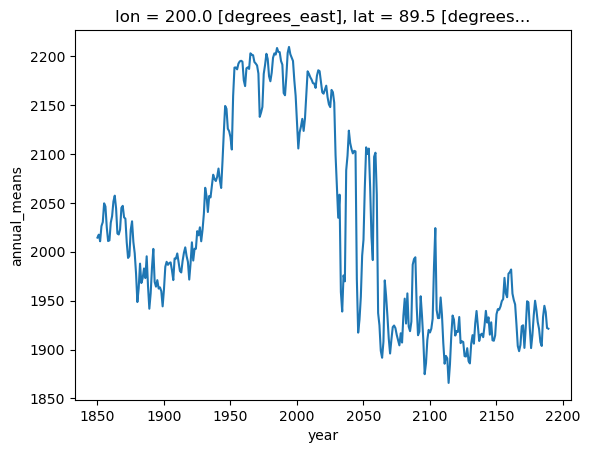

In [17]:
CT_equil['2'].isel(lon=200,lat=-1).annual_means.plot()

In [46]:
# load the pyCO2SYS package
import PyCO2SYS as pyco2
pyco2.hello() # print the version

def get_data(run_params,key,varia,depth_to_analyze,temporal_resolution, yr, step):

    # indicate from which models we get the nutrient field - for the others use World Ocean Atlas (WOA) climatological nutrients
    model_nutrients = ['CNRM-ESM2-1','NorESM2-LM']

    # get the non-model fields (namely for nutriets if it is not CNRM or NorESM
    if varia in ['po4','si'] and run_params[key].model not in model_nutrients:
    
        # get the nutrient data from WOA
        #print('need to get woa data')

        if varia == 'po4':
            ds_po4 = xr.open_dataset('/data/ekoehn/world_ocean_atlas/woa2023/phosphate/annual/woa23_all_p00_01_remapped.nc',decode_times=False)
            da_po4 = ds_po4['p_an'].isel(depth=0).squeeze() #in mumol/kg
            extracted_data = da_po4.expand_dims({'year': step}).transpose('year', 'lat', 'lon')
            extracted_data = extracted_data.assign_coords(year=("year", 1850 + np.arange(yr,yr+step)))
        elif varia == 'si':
            ds_si = xr.open_dataset('/data/ekoehn/world_ocean_atlas/woa2023/silicate/annual/woa23_all_i00_01_remapped.nc',decode_times=False)
            da_si = ds_si['i_an'].isel(depth=0).squeeze() #in mumol/kg      
            extracted_data = da_si.expand_dims({'year': step}).transpose('year', 'lat', 'lon')
            extracted_data = extracted_data.assign_coords(year=("year", 1850 + np.arange(yr,yr+step)))
        else:
            raise Exception('unknown variable')      

    # get the model data
    else:

        # gets the list of files for all runs for this variable
        run_paths = ModelDataGetter._identify_path_strings(run_params,varia,depth_to_analyze,verbose=False) 
    
        # select the run for the chosen key, open from file, extract the variable
        with xr.open_dataset(run_paths[key]) as ds_data: 
            extracted_data = ds_data[temporal_resolution].isel(year=slice(yr, yr+step)) #extract_data_helper(ds_data,temporal_resolution,yr,step)
            extracted_data.load()  # Load into memory before file closes

        # convert alkalinity data and the nutrient data loaded from the models (WOA data already in right mumol per kg format)
        if varia in ['talk','po4','si']:
            #print('convert unit from volumetric to gravimetric (loading density internally) - from mol per m3 to mumol per kg')
            dens_paths = ModelDataGetter._identify_path_strings(run_params,'denis',depth_to_analyze) 
            with xr.open_dataset(dens_paths[key]) as dens_data: 
                extracted_dens = dens_data[temporal_resolution].isel(year=slice(yr, yr+step))
                conv_factor = Converter._Converter__conversion_factors('from_per_m3_to_per_kg',extracted_dens) * Converter._Converter__conversion_factors('from_1_to_micro')
                extracted_data = extracted_data * conv_factor              

    return extracted_data

def get_pressure_data(run_params,key,t_data):

    # get the shape of t_data
    YEARS,LATS,LONS = t_data.shape
    
    # get the depth data
    if run_params[key].model == 'CESM2':
        depth = (t_data.lev/100).values
    else:
        depth = t_data.lev.values

    # get the longitude and latitude data
    lon = t_data.lon #.values
    lat = t_data.lat #.values

    # get the fully 3d lat and depth arrays
    lat3D = t_data['lat'].expand_dims({'year': YEARS, 'lon': LONS}).transpose('year', 'lat', 'lon')
    depth3D = xr.DataArray(depth, dims=()).expand_dims({'year': YEARS, 'lat': LATS, 'lon': LONS}).transpose('year', 'lat', 'lon')

    # compute the pressure using the gsw toolbox
    pressure = gsw.p_from_z(-depth3D, lat3D)  # in dbar
    
    return pressure

def get_atmospheric_CO2_data(run_params,key,yr,step,t_data):

    # get the shape of t_data
    YEARS,LATS,LONS = t_data.shape

    # get xco2 data and make it 3D
    ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
    ds_atmCO2_new = ds_atmCO2[key].shift(year=-1)
    ds_atmCO2_new[-1] = ds_atmCO2[key][-1]
    ds_atmCO2[key] = ds_atmCO2_new

    xco2 = ds_atmCO2[key].isel(year=slice(yr,yr+step))
    xco2_3D = xr.DataArray(xco2, dims=('year')).expand_dims({'lat': LATS, 'lon': LONS}).transpose('year', 'lat', 'lon')
    #print(xco2_3D.shape)

    # now convert to pco2
    factor_to_convert_from_hPa_to_atm = 1/1013.25   # 1 atm = 1013.25 hPa  
    factor_to_convert_from_atm_to_muatm = 10**6   # 
    factor_to_convert_from_hPa_to_muatm = factor_to_convert_from_hPa_to_atm*factor_to_convert_from_atm_to_muatm
    water_vapor_pressure = 0 #6.1 #30#6.1 #hPa
    surface_level_atmospheric_pressure = 1013.25 #980 #1013.25 # hPa
    factor_to_convert_from_ppm = 10**(-6)
    pco2 = xco2_3D*factor_to_convert_from_ppm*(surface_level_atmospheric_pressure-water_vapor_pressure)*factor_to_convert_from_hPa_to_muatm # in ppm * hPa 

    return pco2


def process_year_block(key, yr, step, run_params, depth_to_analyze, temporal_resolution):

    print(f'processing years {yr}-{yr+step-1}')
    
    run_func = True

    # need to get the data for: T, S, AT, PO4, SI, pCO2, PRESSURE (DEPTH)
    t    = get_data(run_params,key,'thetao',depth_to_analyze, temporal_resolution, yr, step) # model # in °C (pot temp)
    s    = get_data(run_params,key,'so',    depth_to_analyze, temporal_resolution, yr, step) # model # in psu
    alk  = get_data(run_params,key,'talk',  depth_to_analyze, temporal_resolution, yr, step) # model # in mumol/kg
    po4  = get_data(run_params,key,'po4',   depth_to_analyze, temporal_resolution, yr, step) # model or WOA2023 dependent on availability # in mumol/kg 
    si   = get_data(run_params,key,'si',    depth_to_analyze, temporal_resolution, yr, step) # model or WOA2023 dependent on availability # in mumol/kg 

    # get the pressure data
    pressure = get_pressure_data(run_params,key,t) # converted from depth and latitude # in dbar

    #print(pressure.shape)
    
    # get the atmospheric CO2 data
    pco2 = get_atmospheric_CO2_data(run_params,key,yr,step,t) # convert from prescribed atmospheric mixing ratio (using sea level pressure and relative humidity) # in ppm * hPa (muatm)

    # choose the options for pyCO2sys
    opt_gas_constant=3
    opt_k_bisulfate=1
    opt_k_carbonic=10
    opt_k_fluoride=1
    opt_pH_scale=1
    opt_total_borate=1
    opt_buffers_mode=1

    # run the pyCO2sys routine (need to flatten the arrays for passing to function)
    if run_func:
        pyCO2sys_results = pyco2.sys(
                        par1=alk.values.flatten(), 
                        par2=pco2.values.flatten(),
                        par1_type=1, 
                        par2_type=4,
                        salinity=s.values.flatten(),
                        temperature=t.values.flatten(),  
                        pressure=pressure.values.flatten(), 
                        temperature_out=t.values.flatten(),
                        pressure_out=pressure.values.flatten(), 
                        total_phosphate=po4.values.flatten(), 
                        total_silicate=si.values.flatten(),
                        opt_gas_constant=opt_gas_constant,
                        opt_k_bisulfate=opt_k_bisulfate,
                        opt_k_carbonic=opt_k_carbonic,
                        opt_k_fluoride=opt_k_fluoride,
                        opt_pH_scale=opt_pH_scale,
                        opt_total_borate=opt_total_borate,
                        opt_buffers_mode=opt_buffers_mode,
                     )

        # reshape the results from pyCO2sys
        reshaped_pyCO2sys_results = pyCO2sys_results['dic'].reshape(t.shape) 

        # put it into an xarray DataArray with the same dimensions and coordinates as for the example temperature
        da_pyCO2sys_result = xr.DataArray(reshaped_pyCO2sys_results, dims=t.dims, coords=t.coords, name="CT_equilibrium")              
        
        return da_pyCO2sys_result
    else:
        return t,s,alk,po4,si,pressure,pco2


def calc_CT_equil(run_params,depth_to_analyze,temporal_resolution):

    # initialize the dictionary for the output
    CT_equil = dict()

    # loop over the model runs to do the calculation for each model
    for key in run_params.keys():
        print(f'Computing the equilibrium CT for model: {run_params[key].model} (key {key})')

        # Do the calculation in a parallelized fashion for speedier performance
        start_year = 0
        end_year = 340
        step = 5
        years = list(range(start_year, end_year, step))
        da_pyCO2sys_result = Parallel(n_jobs=10)(delayed(process_year_block)(key, yr, step, run_params, depth_to_analyze, temporal_resolution) for yr in years)
        concatenated_pyCO2sys_results = xr.concat(da_pyCO2sys_result, dim='year')

        # put the concatenated dataarray into a dataset - this keeps consitency with the CT data
        ds_pyCO2sys_result = xr.Dataset({temporal_resolution: concatenated_pyCO2sys_results})

        # add the unit of the CT_equilibrium
        ds_pyCO2sys_result.attrs["unit"] = "mumol kg-1"
        
        # put the dataset into the dictionary
        CT_equil[key] = ds_pyCO2sys_result

    return CT_equil


CT_equil_shifted_1yr = calc_CT_equil(run_params,depth_to_analyze,temporal_resolution)


               M.P. Humphreys, A.J. Schiller, D.E. Sandborn,
                L. Gregor, D. Pierrot, S.M.A.C. van Heuven,
                        E.R. Lewis & D.W.R. Wallace

                             ~~~ present ~~~

        PyCO2SYS: marine carbonate system calculations in Python.
               Version 1.8.3 :: doi:10.5281/zenodo.3744275


  Py  CCCC       OOOOO        222        SSS      YY      YY      SSS
     CC   C     OO   OO     22   22    SS   SS     YY    YY     SS   SS
    CC         OO     OO         22    SS           YY  YY      SS
    CC         OO     OO        22        S           YY          SSS
    CC         OO     OO       22           SS        YY             SS
     CC   C     OO   OO      22        SS   SS        YY        SS   SS
      CCCC       OOOOO      2222222      SSS          YY          SSS


   Lasciate ogni speranza, voi ch' entrate!
                                    Dante, Inferno iii, 9
                                    sign on the entranc

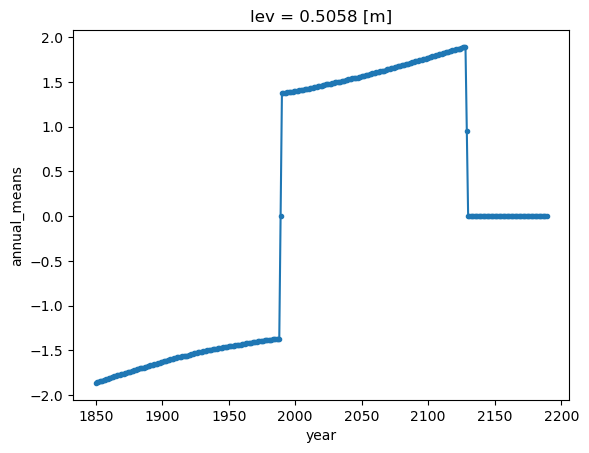

In [50]:
(CT_equil['2'].annual_means - CT_equil_shifted_1yr['2'].annual_means).mean(dim=('lat','lon')).plot(marker='.') # ,year=slice(0,24)
#CT_equil_shifted_1yr['2'].isel(lon=200,lat=-1).annual_means.plot()